In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
import ast
import random
from tqdm import tqdm
import numpy as np

# Exercise 1

## Creating the network from week 4

In [ ]:
df = pd.read_csv('/Users/oskarkarlsson/Desktop/DTU/4. Semester/Social Science/CompSci/Week4/D2_.csv')
df['author_ids'] = df['author_ids'].apply(ast.literal_eval)
df

,id,publication_year,cited_by_count,author_ids
0,https://openalex.org/W2889504592,2020,264,"[https://openalex.org/A5050448347, https://ope..."
1,https://openalex.org/W2015511055,2008,178,"[https://openalex.org/A5113457968, https://ope..."
2,https://openalex.org/W2046064162,2008,156,"[https://openalex.org/A5051165484, https://ope..."
3,https://openalex.org/W2336958366,2016,147,"[https://openalex.org/A5066593729, https://ope..."
4,https://openalex.org/W3087178088,2021,138,"[https://openalex.org/A5066593729, https://ope..."
...,...,...,...,...
151,https://openalex.org/W2898537004,2018,76,"[https://openalex.org/A5059738737, https://ope..."
152,https://openalex.org/W3103900582,2020,74,"[https://openalex.org/A5045349744, https://ope..."
153,https://openalex.org/W4223948429,2022,67,"[https://openalex.org/A5052990671, https://ope..."
154,https://openalex.org/W2603701879,2017,64,"[https://openalex.org/A5018171658, https://ope..."


### Create the graph

In [7]:
G = nx.Graph() # Create an empty graph

pair_counts = defaultdict(int)


for author_list in df['author_ids']: # Iterate through each paper's author list
    for i in range(len(author_list)): # Iterate through each author in the list
        for j in range(i + 1, len(author_list)): # Iterate through pairs of authors
            pair = tuple(sorted([author_list[i].strip(), author_list[j].strip()])) # Create a sorted tuple of unique author pairs
            pair_counts[pair] += 1 # Increment the count for this pair

# Convert the pair counts into a list of weighted edges for the graph
weighted_edgelist = [(a, b, count) for (a, b), count in pair_counts.items()]

# Create weighted edges in the graph
G.add_weighted_edges_from(weighted_edgelist) # Adds edges with weights in the metadata of the graph, also creates nodes
weights = [G[u][v]['weight'] for u, v in G.edges()] # Extract the weights for visualization

### Visualize the graph

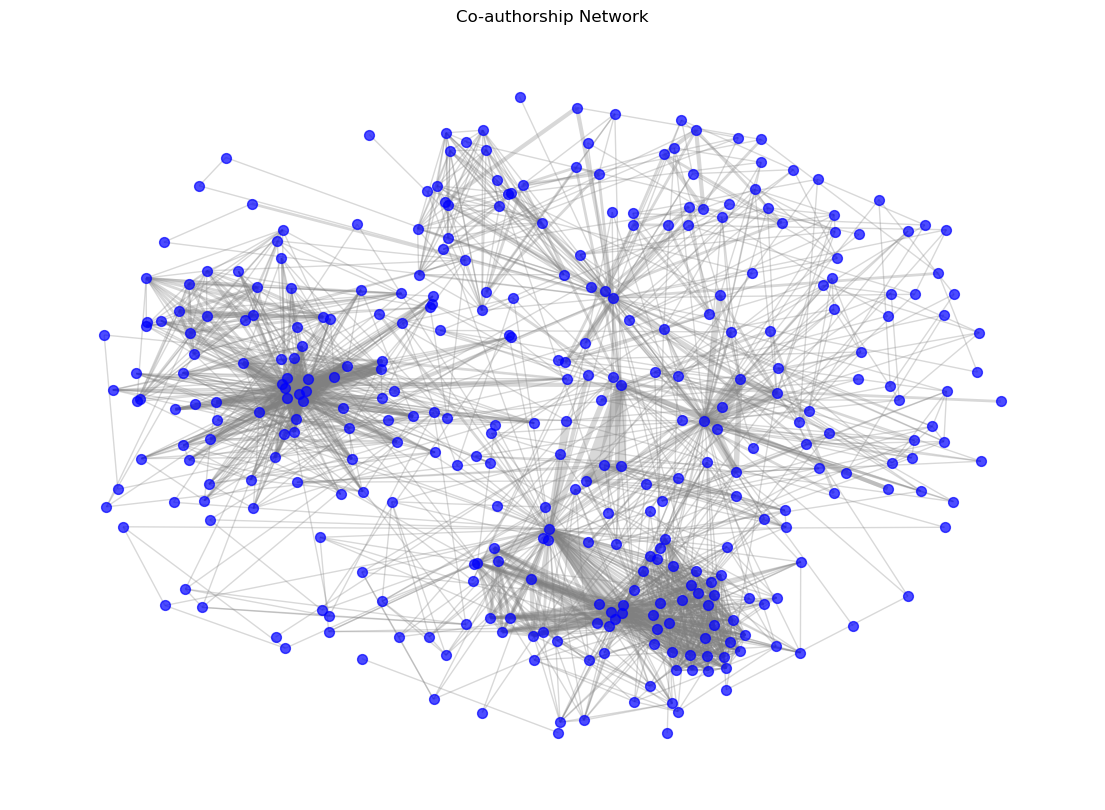

In [8]:
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)  # Position nodes using the spring layout
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='blue', alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', width=weights)
plt.title('Co-authorship Network')
plt.axis('off')
plt.show()

### Add attributes to nodes

In [9]:
for node in G.nodes():
    nx.set_node_attributes(G, {node: G.degree(node)}, 'degree') # change to correct information

## Solving exercises from week 6

### Part 1

In [32]:
# Calculate the Assortativity Coefficient 
# Build degree dict from edge list
degree = defaultdict(int)
for (a, b), count in pair_counts.items():
    degree[a] += count
    degree[b] += count

edges = list(pair_counts.keys())
M = len(edges)

# Compute the three sums over all edges
sum_jk   = sum(degree[a] * degree[b] for a, b in edges)
sum_half = sum((degree[a] + degree[b]) / 2 for a, b in edges)
sum_sq   = sum((degree[a]**2 + degree[b]**2) / 2 for a, b in edges)

r = (M * sum_jk - sum_half**2) / (M * sum_sq - sum_half**2)

print(f"Assortativity coefficient: {r:.4f}")
print("Which means that the network is disassortive, meaning authors with many co-authors")
print("tend to collaborate with authors who have fewer co-authors, and vice versa.")

Assortativity coefficient: -0.0981
Which means that the network is disassortive, meaning authors with many co-authors
tend to collaborate with authors who have fewer co-authors, and vice versa.


### Part 2

In [14]:
def configuration_mode_swap(G):
    G_copy = G.copy()
    edges = list(G_copy.edges())
    E = len(edges)
    num_swaps = E * 10
    swaps_done = 0
    while swaps_done < num_swaps:
        e1, e2 = random.sample(edges, 2)
        a, b = e1
        c, d = e2
        
        # c. Flip e1 50% of the time
        if random.random() < 0.5:
            a, b = b, a
        
        if len(set([a, b, c, d])) == 4:
            if not G_copy.has_edge(a, d) and not G_copy.has_edge(c, b):
                G_copy.remove_edge(*e1)
                G_copy.remove_edge(*e2)
                G_copy.add_edge(a, d)
                G_copy.add_edge(c, b)
                edges.remove(e1)
                edges.remove(e2)
                edges.append((a, d))
                edges.append((c, b))
                swaps_done += 1
    return G_copy

### Part 3

In [30]:
# Each author node does not have a country attribute since data is pulled from the papers dataset, so
# we will assign then countries using the authors dataset

authors_df = pd.read_csv('/Users/oskarkarlsson/Desktop/DTU/4. Semester/Social Science/CompSci/Week4/final_authors.csv')
country_map = dict(zip(authors_df['id'], authors_df['country_code'])) # Map ID to country code

for node in G.nodes():
    G.nodes[node]['country'] = country_map.get(node, None) # Assign country code to node attr., default to None if not found

# Verify
print(list(G.nodes(data=True))[:3])

[('https://openalex.org/A5050448347', {'degree': 2, 'country': None}), ('https://openalex.org/A5066593729', {'degree': 93, 'country': 'CN'}), ('https://openalex.org/A5072503522', {'degree': 2, 'country': None})]


100%|██████████| 100/100 [01:03<00:00,  1.57it/s]


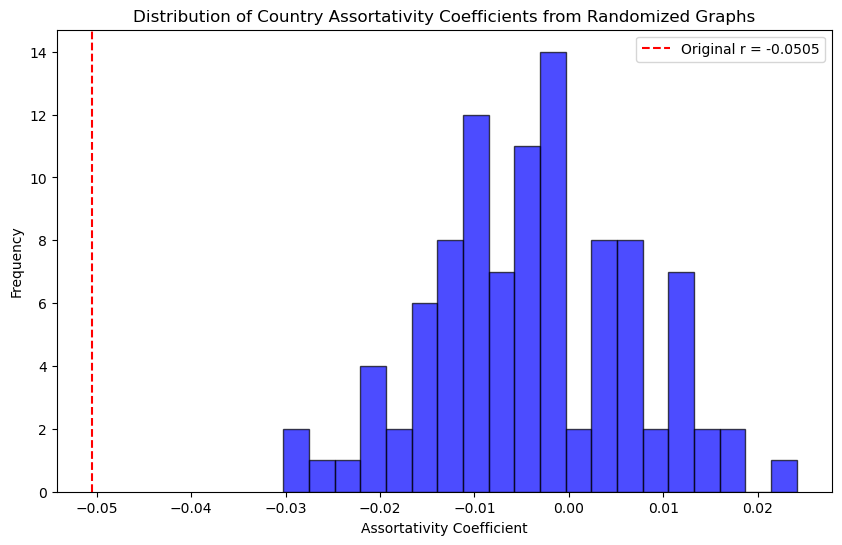

In [39]:
original_r = r

# Generate 100 randomized graphs and compute their assortativity coefficients
randomized_rs = []
for i in tqdm(range(100)):
    G_rand = configuration_mode_swap(G)
    r = nx.attribute_assortativity_coefficient(G_rand, 'country')
    randomized_rs.append(r)

# Plot the distribution of randomized assortativity coefficients
plt.figure(figsize=(10, 6))
plt.hist(randomized_rs, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(original_r, color='red', linestyle='dashed', label=f'Original r = {original_r:.4f}')
plt.title('Distribution of Country Assortativity Coefficients from Randomized Graphs')
plt.xlabel('Assortativity Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Part 4

In [37]:
def degree_assortativity(G):
    edges = list(G.edges())
    ku = np.array([G.degree(u) for u, v in edges])
    kv = np.array([G.degree(v) for u, v in edges])

    numerator = np.mean(ku * kv) - np.mean(ku) * np.mean(kv)
    denominator = np.mean(ku**2) - np.mean(ku)**2
    return numerator / denominator if denominator != 0 else 0

r = degree_assortativity(G)
print(f"Degree assortativity coefficient: {r:.4f}")

Degree assortativity coefficient: -0.0539


100%|██████████| 100/100 [01:02<00:00,  1.60it/s]


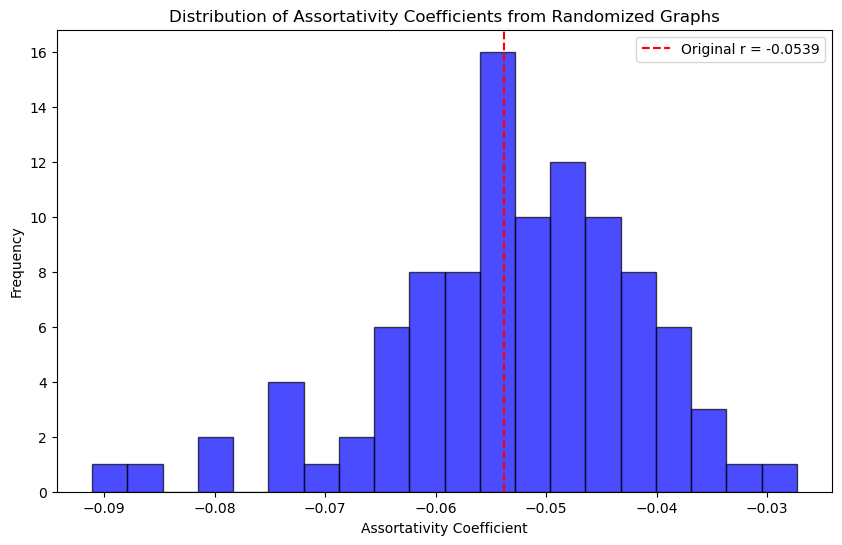

In [ ]:
original_r = degree_assortativity(G)

# Generate 100 randomized graphs and compute their assortativity coefficients
randomized_rs = []
for i in tqdm(range(100)):
    G_rand = configuration_mode_swap(G)
    r = degree_assortativity(G_rand)
    randomized_rs.append(r)

# Plot the distribution of randomized assortativity coefficients
plt.figure(figsize=(10, 6))
plt.hist(randomized_rs, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(original_r, color='red', linestyle='dashed', label=f'Original r = {original_r:.4f}')
plt.title('Distribution of Degree Assortativity Coefficients from Randomized Graphs')
plt.xlabel('Assortativity Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.show()